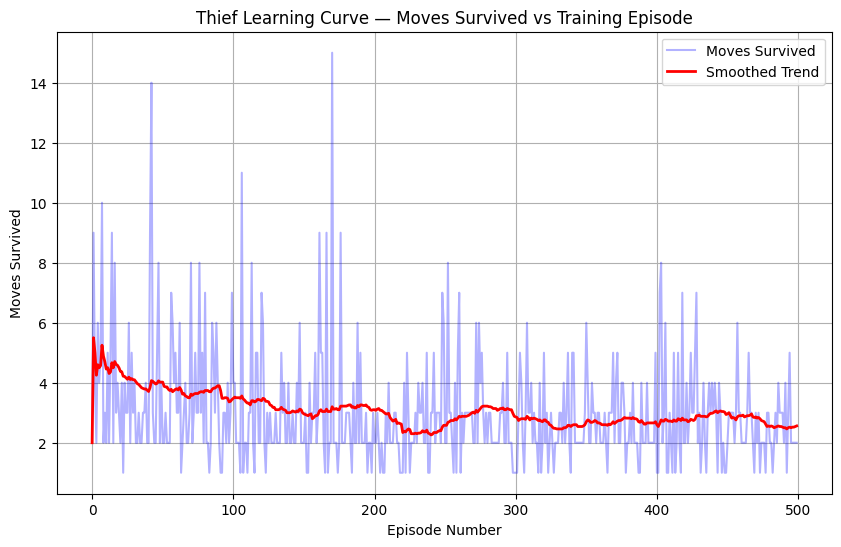

In [1]:
import json
import os

import matplotlib.pyplot as plt

# Load data
episodes = []
moves = []
with open('../results/training_log.jsonl') as f:
    for line in f:
        data = json.loads(line)
        episodes.append(data['episode'])
        moves.append(data['moves'])

# Calculate smoothed trend line (moving average with window 50)
window = 50
smoothed = []
for i in range(len(moves)):
    start = max(0, i - window + 1)
    smoothed.append(sum(moves[start:i+1]) / (i - start + 1))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(episodes, moves, alpha=0.3, color='blue', label='Moves Survived')
plt.plot(episodes, smoothed, color='red', linewidth=2, label='Smoothed Trend')
plt.title('Thief Learning Curve — Moves Survived vs Training Episode')
plt.xlabel('Episode Number')
plt.ylabel('Moves Survived')
plt.legend()
plt.grid(True)

# Save plot
os.makedirs('../assets', exist_ok=True)
plt.savefig('../assets/learning_curve.png')
plt.show()


## Cop Strategies Evaluation

To ensure the Thief was trained against a realistic yet beatable opponent, we utilized a **Dual-Cop Design**:
1. **Training Cop (50/50 Epsilon-Random)**: During the 500 Q-table training episodes, the Cop moves toward the Thief using a Manhattan heuristic 50% of the time, and picks a random valid action 50% of the time. This allows the Thief to explore the board and learn effective survival strategies without being immediately cornered.
2. **Sweep Cop (Deterministic)**: During the actual evaluation games, the Cop drops a 3-barrier wall down column 2 and executes a relentless 3x3 vision sweep. 

The bar chart below compares the Thief's average survival time against the Training Cop (averaged over the last 50 training episodes) versus the deterministic Sweep Cop during the evaluation phase.

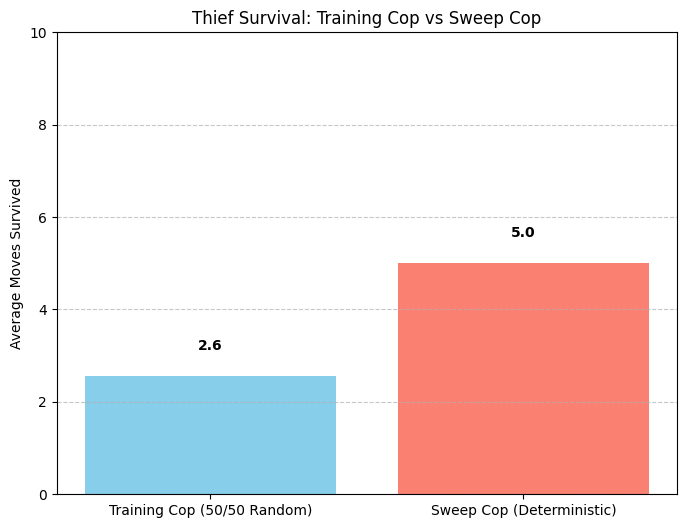

In [2]:
import json

import matplotlib.pyplot as plt

# Load training data to get average moves survived against Training Cop
moves = []
with open('../results/training_log.jsonl') as f:
    for line in f:
        data = json.loads(line)
        moves.append(data['moves'])

# Average over the last 50 episodes of training
if len(moves) >= 50:
    avg_training_moves = sum(moves[-50:]) / 50
else:
    avg_training_moves = sum(moves) / len(moves) if moves else 0

# Average moves survived against the Sweep Cop (30 points over 6 games = 5 moves/game)
avg_sweep_moves = 5.0

# Plotting
labels = ['Training Cop (50/50 Random)', 'Sweep Cop (Deterministic)']
values = [avg_training_moves, avg_sweep_moves]

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=['skyblue', 'salmon'])

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5, f'{yval:.1f}',
        ha='center', va='bottom',
        fontweight='bold'
    )

plt.title('Thief Survival: Training Cop vs Sweep Cop')
plt.ylabel('Average Moves Survived')
plt.ylim(0, max(values) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save plot
plt.savefig('../assets/strategy_comparison.png')
plt.show()


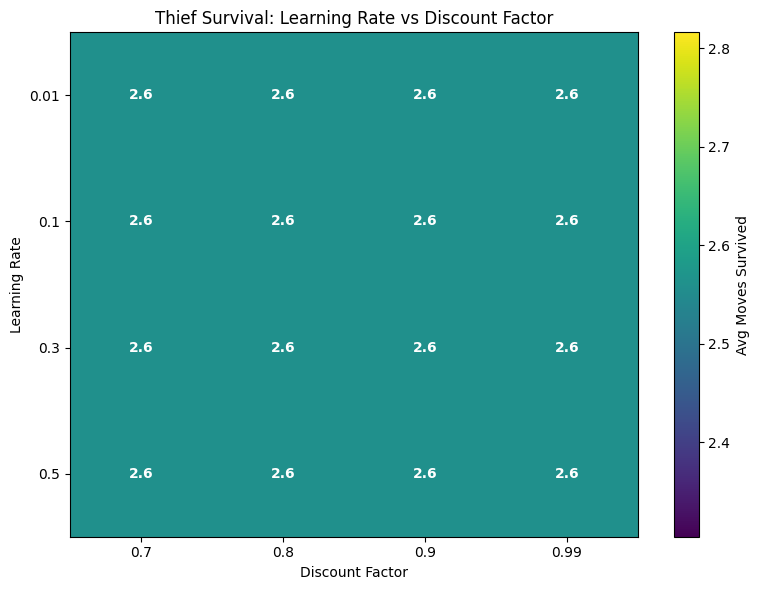

In [3]:
import sys

sys.path.insert(0, '../src')
import matplotlib.pyplot as plt
import numpy as np

from cop_thief.services.q_table import QTable
from cop_thief.services.training_engine import TrainingEngine
from cop_thief.shared.config_loader import ConfigLoader

lrs = [0.01, 0.1, 0.3, 0.5]
dfs = [0.7, 0.8, 0.9, 0.99]
results = np.zeros((len(lrs), len(dfs)))

for i, lr in enumerate(lrs):
    for j, df in enumerate(dfs):
        config = ConfigLoader("../config/config.json")
        config.load()
        config._config["training"]["num_episodes"] = 100
        config._config["rl"]["learning_rate"] = lr
        config._config["rl"]["discount_factor"] = df
        q_table = QTable(config)
        engine = TrainingEngine(config, q_table)
        engine.run_headless_games()
        import json
        moves = []
        with open('../results/training_log.jsonl') as f:
            for line in f:
                moves.append(json.loads(line)["moves"])
        results[i, j] = np.mean(moves[-50:])

plt.figure(figsize=(8, 6))
plt.imshow(results, cmap='viridis', aspect='auto')
plt.colorbar(label='Avg Moves Survived')
plt.xticks(range(len(dfs)), dfs)
plt.yticks(range(len(lrs)), lrs)
plt.title('Thief Survival: Learning Rate vs Discount Factor')
plt.xlabel('Discount Factor')
plt.ylabel('Learning Rate')
for i in range(len(lrs)):
    for j in range(len(dfs)):
        plt.text(
            j, i, f'{results[i,j]:.1f}',
            ha='center', va='center', color='white', fontweight='bold'
        )
plt.tight_layout()
plt.savefig('../assets/hyperparameter_heatmap.png')
plt.show()